In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

In [6]:
# Define column names based on the header in the SRL file
column_names = [
    "Source_id", "Isl_id", "RA", "E_RA", "DEC", "E_DEC", "Total_flux", "E_Total_flux",
    "Peak_flux", "E_Peak_flux", "RA_max", "E_RA_max", "DEC_max", "E_DEC_max", "Maj", 
    "E_Maj", "Min", "E_Min", "PA", "E_PA", "Maj_img_plane", "E_Maj_img_plane", 
    "Min_img_plane", "E_Min_img_plane", "PA_img_plane", "E_PA_img_plane", "DC_Maj", 
    "E_DC_Maj", "DC_Min", "E_DC_Min", "DC_PA", "E_DC_PA", "DC_Maj_img_plane", 
    "E_DC_Maj_img_plane", "DC_Min_img_plane", "E_DC_Min_img_plane", "DC_PA_img_plane", 
    "E_DC_PA_img_plane", "Isl_Total_flux", "E_Isl_Total_flux", "Isl_rms", "Isl_mean", 
    "Resid_Isl_rms", "Resid_Isl_mean", "S_Code"
]

In [7]:
# Assuming 'file.srl' is the SRL file
srl_file_path_2 = '../server/source_detection/spw/4-spw2-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl'
srl_file_path_3 = '../server/source_detection/spw/4-spw3-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl'
srl_file_path_4 = '../server/source_detection/spw/4-spw4-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl'
srl_file_path_5 = '../server/source_detection/spw/4-spw5-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl'
srl_file_path_6 = '../server/source_detection/spw/4-spw6-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl'
srl_file_path_8 = '../server/source_detection/spw/4-spw8-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl'
srl_file_path_15 = '../server/source_detection/spw/4-spw15-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl'
srl_file_path_16 = '../server/source_detection/spw/4-spw16-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl'
srl_file_path_17 = '../server/source_detection/spw/4-spw17-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl'

In [8]:
df_2 = pd.read_csv(srl_file_path_2, delim_whitespace=True, comment='#', names=column_names)
df_3 = pd.read_csv(srl_file_path_3, delim_whitespace=True, comment='#', names=column_names)
df_4 = pd.read_csv(srl_file_path_4, delim_whitespace=True, comment='#', names=column_names)
df_5 = pd.read_csv(srl_file_path_5, delim_whitespace=True, comment='#', names=column_names)
df_6 = pd.read_csv(srl_file_path_6, delim_whitespace=True, comment='#', names=column_names)
df_8 = pd.read_csv(srl_file_path_8, delim_whitespace=True, comment='#', names=column_names)
df_15 = pd.read_csv(srl_file_path_15, delim_whitespace=True, comment='#', names=column_names)
df_16 = pd.read_csv(srl_file_path_16, delim_whitespace=True, comment='#', names=column_names)
df_17 = pd.read_csv(srl_file_path_17, delim_whitespace=True, comment='#', names=column_names)

In [9]:
def round_ra_dec(dataframe, decimal=2):
    
    dataframe['RA_rounded'] = dataframe['RA'].round(decimal)
    dataframe['DEC_rounded'] = dataframe['DEC'].round(decimal)
    
    return dataframe

In [10]:
df_2 = round_ra_dec(df_2)
df_3 = round_ra_dec(df_3)
df_4 = round_ra_dec(df_4)
df_5 = round_ra_dec(df_5)
df_6 = round_ra_dec(df_6)
df_8 = round_ra_dec(df_8)
df_15 = round_ra_dec(df_15)
df_16 = round_ra_dec(df_16)
df_17 = round_ra_dec(df_17)

In [11]:
df_2_ra_dec_flux = df_2[['RA_rounded', 'DEC_rounded', 'Total_flux']]
df_3_ra_dec_flux = df_3[['RA_rounded', 'DEC_rounded', 'Total_flux']]
df_4_ra_dec_flux = df_4[['RA_rounded', 'DEC_rounded', 'Total_flux']]
df_5_ra_dec_flux = df_5[['RA_rounded', 'DEC_rounded', 'Total_flux']]
df_6_ra_dec_flux = df_6[['RA_rounded', 'DEC_rounded', 'Total_flux']]
df_8_ra_dec_flux = df_8[['RA_rounded', 'DEC_rounded', 'Total_flux']]
df_15_ra_dec_flux = df_15[['RA_rounded', 'DEC_rounded', 'Total_flux']]
df_16_ra_dec_flux = df_16[['RA_rounded', 'DEC_rounded', 'Total_flux']]
df_17_ra_dec_flux = df_17[['RA_rounded', 'DEC_rounded', 'Total_flux']]

In [19]:
df_2_ra_dec_flux.iloc[100]

RA_rounded     51.500000
DEC_rounded    29.520000
Total_flux      0.002913
Name: 100, dtype: float64

In [15]:
def get_total_flux_values(df_list, ra_value, dec_value, dates):
    total_flux_values = []
    for df in df_list:
        print(df)
        total_flux = df.loc[(df['RA_rounded'] == ra_value) & (df['DEC_rounded'] == dec_value), 'Total_flux'].iloc[0]
        total_flux_values.append(total_flux)
    return total_flux_values

def plot_total_flux(x, total_flux_values):
    plt.figure(figsize=(10, 6))
    plt.scatter(x, total_flux_values, c='red')
    plt.plot(total_flux_values)
    plt.ylabel('Total Flux [Jy/Beam]', fontsize=15)
    plt.xlabel('Date', fontsize=15)
    plt.xticks(rotation=45)
    plt.show()


In [22]:
x = ['spw2', 'spw3', 'spw4', 'spw5', 'spw6', 'spw8', 'spw15', 'spw16', 'spw17']
total_flux_values_1 = get_total_flux_values([df_2_ra_dec_flux, df_3_ra_dec_flux, df_4_ra_dec_flux, df_5_ra_dec_flux, df_6_ra_dec_flux, df_8_ra_dec_flux, df_15_ra_dec_flux, df_16_ra_dec_flux, df_17_ra_dec_flux], 52.56, 29.54, x)
total_flux_values_2 = get_total_flux_values([df_2_ra_dec_flux, df_3_ra_dec_flux, df_4_ra_dec_flux, df_5_ra_dec_flux, df_6_ra_dec_flux, df_8_ra_dec_flux, df_15_ra_dec_flux, df_16_ra_dec_flux, df_17_ra_dec_flux], 50.39, 28.96, x)
total_flux_values_3 = get_total_flux_values([df_2_ra_dec_flux, df_3_ra_dec_flux, df_4_ra_dec_flux, df_5_ra_dec_flux, df_6_ra_dec_flux, df_8_ra_dec_flux, df_15_ra_dec_flux, df_16_ra_dec_flux, df_17_ra_dec_flux], 51.50, 29.52, x)

     RA_rounded  DEC_rounded  Total_flux
0         52.56        29.54    0.002557
1         52.46        29.13    0.003505
2         52.46        29.82    0.005155
3         52.41        29.85    0.001433
4         52.27        29.74    0.002703
..          ...          ...         ...
233       50.39        29.30    0.002762
234       50.39        28.96    0.001628
235       50.24        29.23    0.002778
236       50.26        29.23    0.001090
237       50.15        29.52    0.001239

[238 rows x 3 columns]
     RA_rounded  DEC_rounded  Total_flux
0         52.56        29.54    0.001955
1         52.46        29.13    0.002581
2         52.47        29.82    0.004091
3         52.41        29.85    0.001467
4         52.30        29.63    0.001413
..          ...          ...         ...
259       50.31        28.99    0.001600
260       50.30        29.06    0.001144
261       50.30        29.01    0.002069
262       50.24        29.23    0.003712
263       50.24        29.27    0

IndexError: single positional indexer is out-of-bounds

In [23]:
total_flux_1

NameError: name 'total_flux_1' is not defined

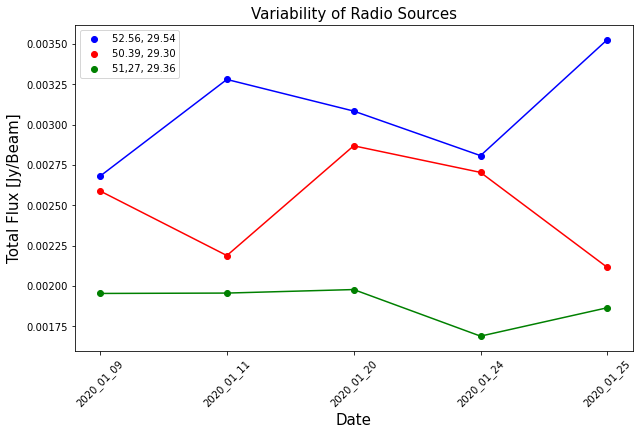

In [13]:
# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "font.serif": ["Computer Modern Roman"],
# })

plt.figure(figsize=(10, 6))
plt.scatter(x, total_flux_values, c='b', label = '52.56, 29.54')
plt.plot(total_flux_values, 'b')

plt.scatter(x, total_flux_values_2, c='red', label='50.39, 29.30')
plt.plot(total_flux_values_2, 'red')

plt.scatter(x, total_flux_values_3, c='g', label='51,27, 29.36')
plt.plot(total_flux_values_3, 'g')

plt.ylabel('Total Flux [Jy/Beam]', fontsize=15)
plt.xlabel('Date', fontsize=15)
plt.title('Variability of Radio Sources', fontsize=15)


plt.xticks(rotation=45)
plt.legend()
plt.savefig('../server/figure/variability.png')
plt.show()
